<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/hidden_input_hidden_pb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tempfile
import os

import tensorflow as tf
from tensorflow import keras

In [2]:
import numpy as np
import tensorflow as tf

try:
    import tf_keras as keras
except ImportError:
    from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Match paper setup: use 50k training samples
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (50000, 28, 28) (50000,)
Test : (10000, 28, 28) (10000,)


In [4]:
def build_float_ann():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(10)   # logits
    ])
    return model

float_model = build_float_ann()
float_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
float_model = build_float_ann()

float_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train model
float_history = float_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    verbose=1
)

float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)

print(f"FLOAT Test accuracy: {float_test_acc:.4f} | loss: {float_test_loss:.4f}")

Epoch 1/40
1563/1563 [==============================] - 6s 3ms/step - loss: 0.4326 - accuracy: 0.8868
Epoch 2/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.2156 - accuracy: 0.9385
Epoch 3/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1605 - accuracy: 0.9533
Epoch 4/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1263 - accuracy: 0.9633
Epoch 5/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1016 - accuracy: 0.9709
Epoch 6/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0836 - accuracy: 0.9767
Epoch 7/40
1563/1563 [==============================] - 5s 4ms/step - loss: 0.0689 - accuracy: 0.9805
Epoch 8/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0576 - accuracy: 0.9847
Epoch 9/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0490 - accuracy: 0.9874
Epoch 10/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.041

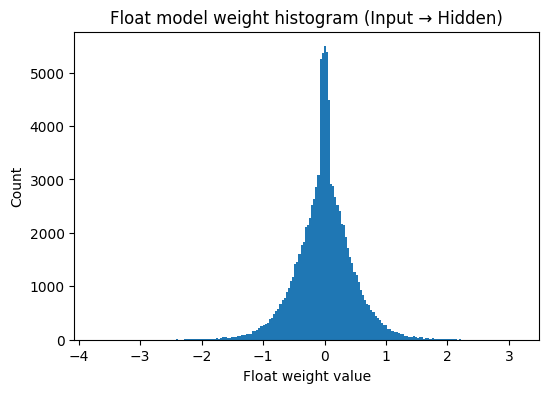

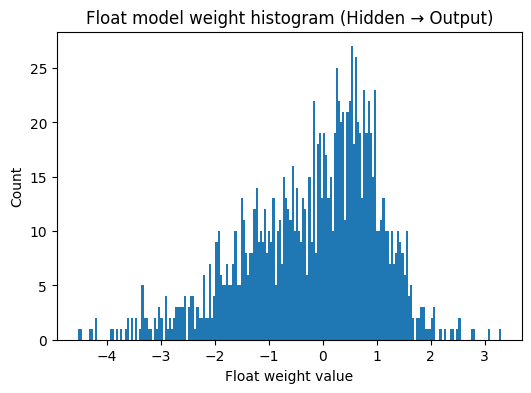

In [6]:
import matplotlib.pyplot as plt

dense_layers = []

for layer in float_model.layers:

    if isinstance(layer, keras.layers.Dense):
        dense_layers.append(layer)

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-4, 4])
plt.show()

w2 = dense_layers[1].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()

In [7]:
float_history.model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
print("******** Non discretized weights for input to hidden layer ************ \n\n")

layer_weights1, biases1 = dense_layers[0].get_weights()
print(layer_weights1)
#weights only for one layer

print("\n\n*********** Non discretized weights for hidden to output layer *********** \n\n")
#and weight of second layer
layer_weights2, biases2 = dense_layers[1].get_weights()
print(layer_weights2)

******** Non discretized weights for input to hidden layer ************ 


[[-0.06709702 -0.07344833 -0.06898546 ...  0.05887804  0.01240268
  -0.06896897]
 [ 0.02325626 -0.02656236 -0.02013792 ... -0.03470364  0.06516912
  -0.04256155]
 [ 0.00059587 -0.026409   -0.07059383 ...  0.07939298 -0.00563326
  -0.03064701]
 ...
 [-0.00326814  0.00351938 -0.04821201 ...  0.04391942  0.06544734
  -0.07611814]
 [ 0.05255616 -0.05686771  0.02127321 ...  0.05144549  0.05802768
   0.07137875]
 [ 0.03087679  0.00045447  0.08074207 ...  0.05955031  0.05293012
   0.07982945]]


*********** Non discretized weights for hidden to output layer *********** 


[[-2.2011251   0.11126578 -1.3359857  ...  0.64416474  0.48721054
   0.8581318 ]
 [-2.1357255   0.8431244   2.0490625  ...  0.8880542   0.35956684
  -4.319991  ]
 [ 0.36770302  0.05961242  0.1456426  ...  0.18141101  0.5952213
  -1.9251212 ]
 ...
 [ 0.3527715   1.0654374   1.6229823  ... -1.7041599   0.03558296
   0.6900114 ]
 [ 1.0754782   1.3884647 

In [9]:
# levels1 = [-0.1 , -0.075, -0.025, 0.0 , 0.025, 0.075, 0.1]
levels1 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]
levels2 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]


def snap_weights_to_levels(weights, levels):


    levels = np.array(levels)
    snapped = np.zeros_like(weights)

    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            w = weights[i, j]


            if w <= levels[0]:
                snapped[i, j] = levels[0]
                continue
            if w >= levels[-1]:
                snapped[i, j] = levels[-1]
                continue


            for k in range(len(levels) - 1):
                low = levels[k]
                high = levels[k + 1]

                if low <= w <= high:
                    midpoint = (low + high) / 2

                    if w > midpoint:
                        snapped[i, j] = high
                    else:
                        snapped[i, j] = low
                    break

    return snapped



In [10]:
snapped_weights1 = snap_weights_to_levels(layer_weights1, levels1)
snapped_weights2 = snap_weights_to_levels(layer_weights2, levels2)


In [11]:
print("\n\n")
print(snapped_weights1)
print("\n\n")
print(snapped_weights2)




[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]



[[-1.    0.   -1.   ...  0.75  0.25  0.75]
 [-1.    0.75  1.   ...  1.    0.25 -1.  ]
 [ 0.25  0.    0.25 ...  0.25  0.75 -1.  ]
 ...
 [ 0.25  1.    1.   ... -1.    0.    0.75]
 [ 1.    1.   -0.75 ... -0.25 -1.    1.  ]
 [-1.    1.   -1.   ...  0.25 -0.25  0.25]]


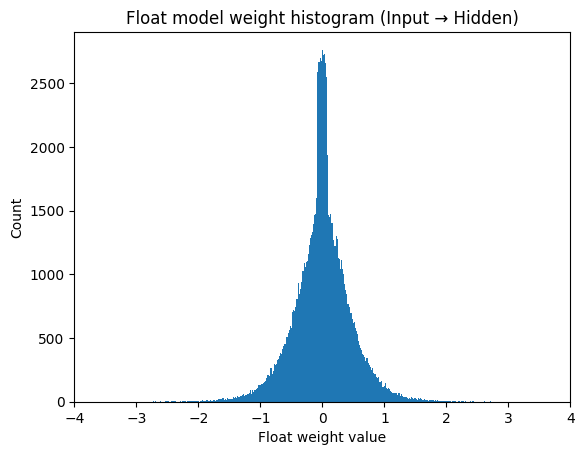

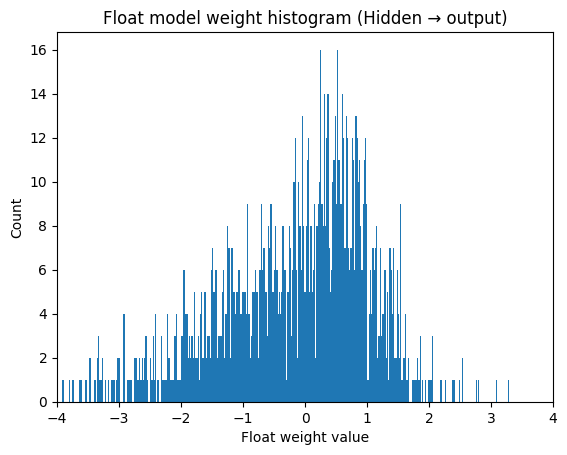

In [12]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)
w2 = dense_layers[1].get_weights()[0].reshape(-1)


plt.hist(w1, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-4, 4])
plt.show()

plt.hist(w2, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → output)")
plt.xlim([-4, 4])
plt.show()

In [13]:
dense_layers[0].set_weights([snapped_weights1, biases1])
dense_layers[1].set_weights([snapped_weights2, biases2])

In [14]:
loss, acc = float_model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.1881 - accuracy: 0.9473
Accuracy: 0.9473000168800354


In [15]:
float_history = float_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0092 - accuracy: 0.9982
Epoch 2/5
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0026 - accuracy: 1.0000
Epoch 3/5
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0019 - accuracy: 1.0000
Epoch 4/5
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0014 - accuracy: 1.0000
Epoch 5/5
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0011 - accuracy: 1.0000


In [16]:
loss, acc = float_model.evaluate(x_test, y_test)
print("Accuracy:", acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0933 - accuracy: 0.9777
Accuracy: 0.9776999950408936


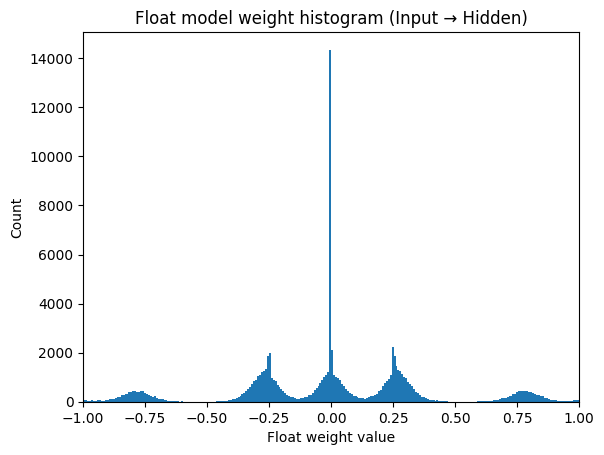

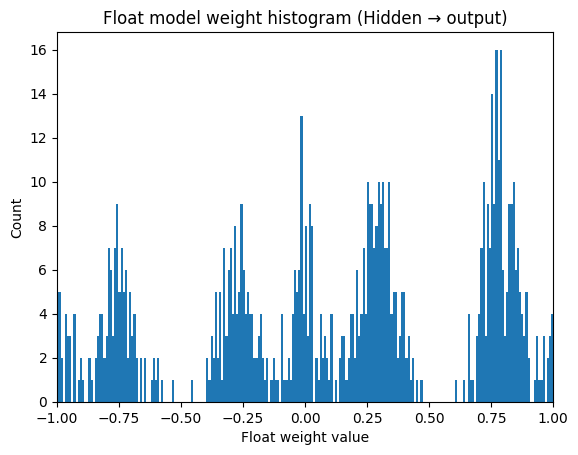

In [17]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)
w2 = dense_layers[1].get_weights()[0].reshape(-1)


plt.hist(w1, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-1, 1])
plt.show()

plt.hist(w2, bins=400)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → output)")
plt.xlim([-1, 1])
plt.show()

Now both layers are discretized. to levels 1 and level2 (according to their scale)

Training again